In [ ]:
!pip install pyspark --quiet

print('Pyspark installation completed')

Pyspark installation completed


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month, to_date, col, round as spark_round

import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

spark=SparkSession.builder\
    .appName('Day4_BigData_Sales')\
    .config('spark.sql.adaptive.enabled', 'true')\
    .getOrCreate()

print(f'Spark version : {spark.version}')
print(f'Sparksession : ACTIVE')

Spark version : 4.0.2
Sparksession : ACTIVE


In [ ]:
df_bronze=spark.read\
    .option('header', 'true')\
    .option('inferSchema', 'true')\
    .csv('large_sales_data.csv')

print('==BRONZE LAYER- Raw Data==')
print(f'Rows : {df_bronze.count()}')

print(f'Columns: {len(df_bronze.columns)}')
print(f'Names : {df_bronze.columns}')
print()
df_bronze.printSchema()



==BRONZE LAYER- Raw Data==
Rows : 5000
Columns: 13
Names : ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print('First 5 rows:')
df_bronze.show(5, truncate=False)

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [ ]:
print('\nBasic statistics for numeric columns:')
df_bronze.select('quantity', 'unit_price', 'revenue').describe().show()


Basic statistics for numeric columns:
+-------+-----------------+------------------+------------------+
|summary|         quantity|        unit_price|           revenue|
+-------+-----------------+------------------+------------------+
|  count|             5000|              5000|              5000|
|   mean|           7.9536|          12496.86|          99169.52|
| stddev|4.275313169878912|14857.384309295603|145972.97195261103|
|    min|                1|               600|               600|
|    max|               15|             45000|            675000|
+-------+-----------------+------------------+------------------+



In [ ]:
df_bronze.write \
   .mode('overwrite') \
   .parquet('sales_bronze.parquet')

print('Bronze Parquet saved: sales_bronze.parquet')

import os

def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path)/1024

  total=0
  for dirpath,dirnames,filenames in os.walk(path):
    for f in filenames:
      total+=os.path.getsize(os.path.join(dirpath,f))
  return total / 1024

csv_size= get_dir_size('large_sales_data.csv')
parquet_size= get_dir_size('sales_bronze.parquet')
reduction=(1-parquet_size/csv_size)*100

print(f'\nCSV size : {csv_size:.1f} KB')
print(f'Parquet size : {parquet_size:.1f} KB')
print(f'Reduction : {reduction:.1f}% smaller')
print(f'\nAt 1 TB scale: CSV=1000 GB -> Parquet={1000*(1-reduction/100):.0f} GB')

Bronze Parquet saved: sales_bronze.parquet

CSV size : 529.3 KB
Parquet size : 55.1 KB
Reduction : 89.6% smaller

At 1 TB scale: CSV=1000 GB -> Parquet=104 GB


In [ ]:
df_silver=df_bronze \
   .dropDuplicates() \
   .dropna(subset=['order_id','product','revenue'])

df_silver=df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-MM--dd')
)

df_silver=df_silver \
    .withColumn('order_year', year(col('order_date'))) \
    .withColumn('order_month', month(col('order_date')))

df_silver=df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue')>40000, 'High')
    .when(col('revenue')>10000, 'Medium')
    .otherwise('Low')
)

print(f'Silver Layer rows: {df_silver.count()}')
print(f'New columns added : order_year, order_month, revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category')

Silver Layer rows: 5000
New columns added : order_year, order_month, revenue_category


DataFrame[product: string, revenue: int, order_year: int, order_month: int, revenue_category: string]

In [ ]:
df_silver.write \
    .mode('overwrite') \
    .parquet('sales_silver.parquet')

print('Silver Parquet saved: sales_silver.parquet')
print(f'Silver size: {get_dir_size("sales_silver.parquet"):.1f} KB')

df_verify=spark.read.parquet('sales_silver.parquet')
print('\n===Verify silver layer===')
print(f'Read-back rows: {df_verify.count()} (should match Silver count)')
df_verify.printSchema()

Silver Parquet saved: sales_silver.parquet
Silver size: 59.8 KB

===Verify silver layer===
Read-back rows: 5000 (should match Silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
top_products=df_silver \
    .groupBy('product') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        F.avg('revenue').alias('avg_order_revenue')
    ) \
    .orderBy('total_revenue', ascending=False) \
    .limit(5)

print('===Top 5 products by revenue===')
top_products.show(truncate=False)


===Top 5 products by revenue===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |182700000    |502       |363944.22310756973|
|Tablet |135104000    |532       |253954.8872180451 |
|Monitor|82126000     |481       |170740.12474012474|
|Printer|44544000     |488       |91278.68852459016 |
|Speaker|16317000     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [ ]:
region_revenue=df_silver \
    .groupBy('region') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        F.countDistinct('customer_name').alias('num_customers')
    ) \
    .orderBy('total_revenue', ascending=False)

print('===Revenue by region===')
region_revenue.show(truncate=False)

===Revenue by region===
+------+-------------+----------+-------------+
|region|total_revenue|num_orders|num_customers|
+------+-------------+----------+-------------+
|West  |198275600    |2021      |15           |
|South |147145900    |1483      |15           |
|North |99878400     |995       |15           |
|East  |50547700     |501       |15           |
+------+-------------+----------+-------------+



In [ ]:
monthly_trend=df_silver \
    .groupBy('order_month') \
    .agg(
        F.sum('revenue').alias('monthly_revenue'),
        F.count('order_id').alias('monthly_orders'),
    ) \
    .orderBy('order_month')

print('=== Monthly Revenue Trend===')
monthly_trend.show(truncate=False)

=== Monthly Revenue Trend===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|1          |41068200       |423           |
|2          |34485400       |375           |
|3          |40031200       |451           |
|4          |38857100       |390           |
|5          |39984500       |423           |
|6          |40707400       |390           |
|7          |42640700       |405           |
|8          |43718500       |418           |
|9          |37640200       |398           |
|10         |47839000       |479           |
|11         |44577100       |419           |
|12         |44298300       |429           |
+-----------+---------------+--------------+



In [ ]:
gold_region=region_revenue
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print('Gold 1 saved: gold_region_revenue.parquet')

gold_products=df_silver \
    .groupBy('product','category') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('units_sold'),
        spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
        F.max('revenue').alias('largest_order')
    ) \
    .orderBy('total_revenue', ascending=False) \

gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')
print('Gold 2 saved: gold_product_summary.parquet')

gold_monthly=monthly_trend
gold_monthly.write.mode('overwrite').parquet('monthly_trend.parquet')
print('Gold 3 saved: monthly_trend.parquet')

Gold 1 saved: gold_region_revenue.parquet
Gold 2 saved: gold_product_summary.parquet
Gold 3 saved: monthly_trend.parquet


In [ ]:
region_pd=spark.read.parquet('gold_region_revenue.parquet').toPandas()
products_pd=spark.read.parquet('gold_product_summary.parquet').toPandas()
monthly_pd=spark.read.parquet('monthly_trend.parquet').toPandas()

print('Gold tables converted to Pandas:')
print(f' Region : {region_pd.shape}')
print(f' Products : {products_pd.shape}')
print(f' Monthly : {monthly_pd.shape}')

region_pd= region_pd.sort_values(by='total_revenue', ascending=False)
products_pd= products_pd.sort_values(by='total_revenue', ascending=False)
monthly_pd= monthly_pd.sort_values(by='order_month')


Gold tables converted to Pandas:
 Region : (4, 4)
 Products : (10, 6)
 Monthly : (12, 3)


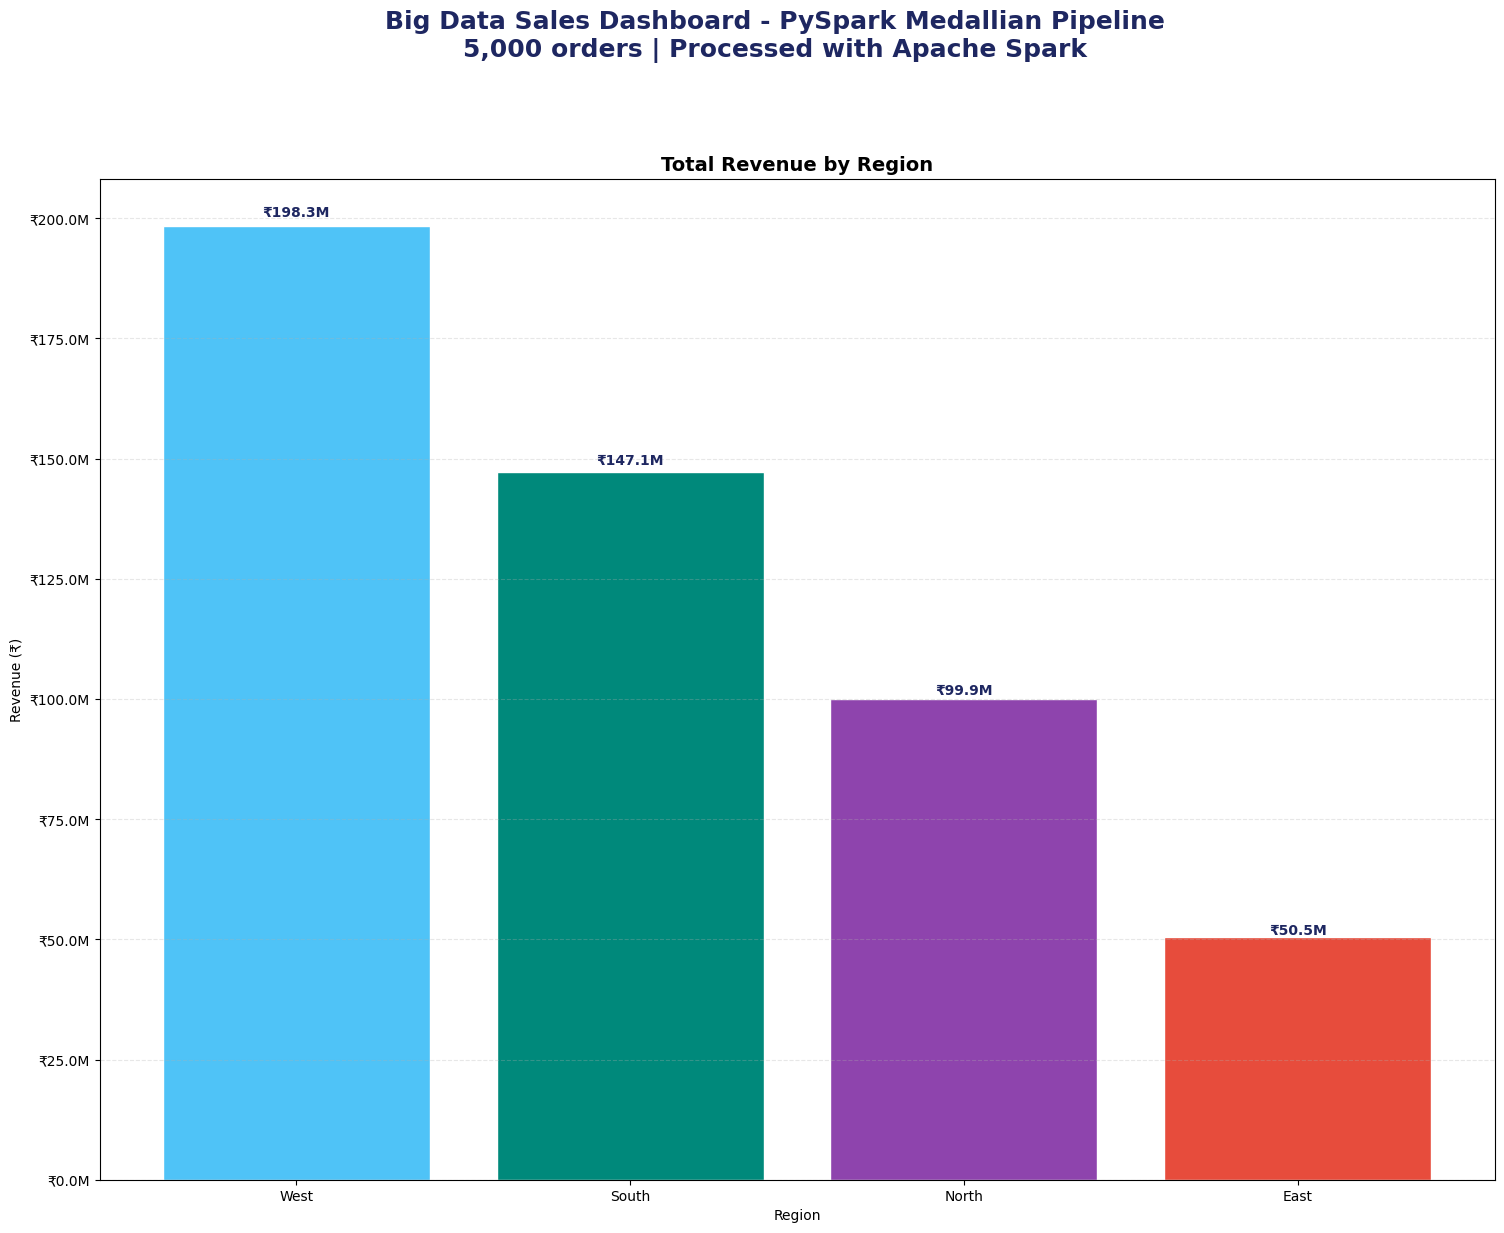

In [ ]:
fig,axes = plt.subplots(1,1,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallian Pipeline\n'
    '5,000 orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold', color='#1E2761', y=1.01
)

colors4= ['#4FC3F7','#00897B','#8E44AD','#E74C3C']

ax1=axes
bars1= ax1.bar(region_pd['region'],region_pd['total_revenue'],
               color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
           f'₹{bar.get_height()/1e6:.1f}M',
           ha='center',fontsize=10,fontweight='bold',color='#1E2761')

ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue (₹)')
ax1.set_xlabel('Region')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y', linestyle='--', alpha=0.3)


(np.float64(-1.0999916410719184),
 np.float64(1.0999913933849192),
 np.float64(-1.0999989953402518),
 np.float64(1.0999999521590595))

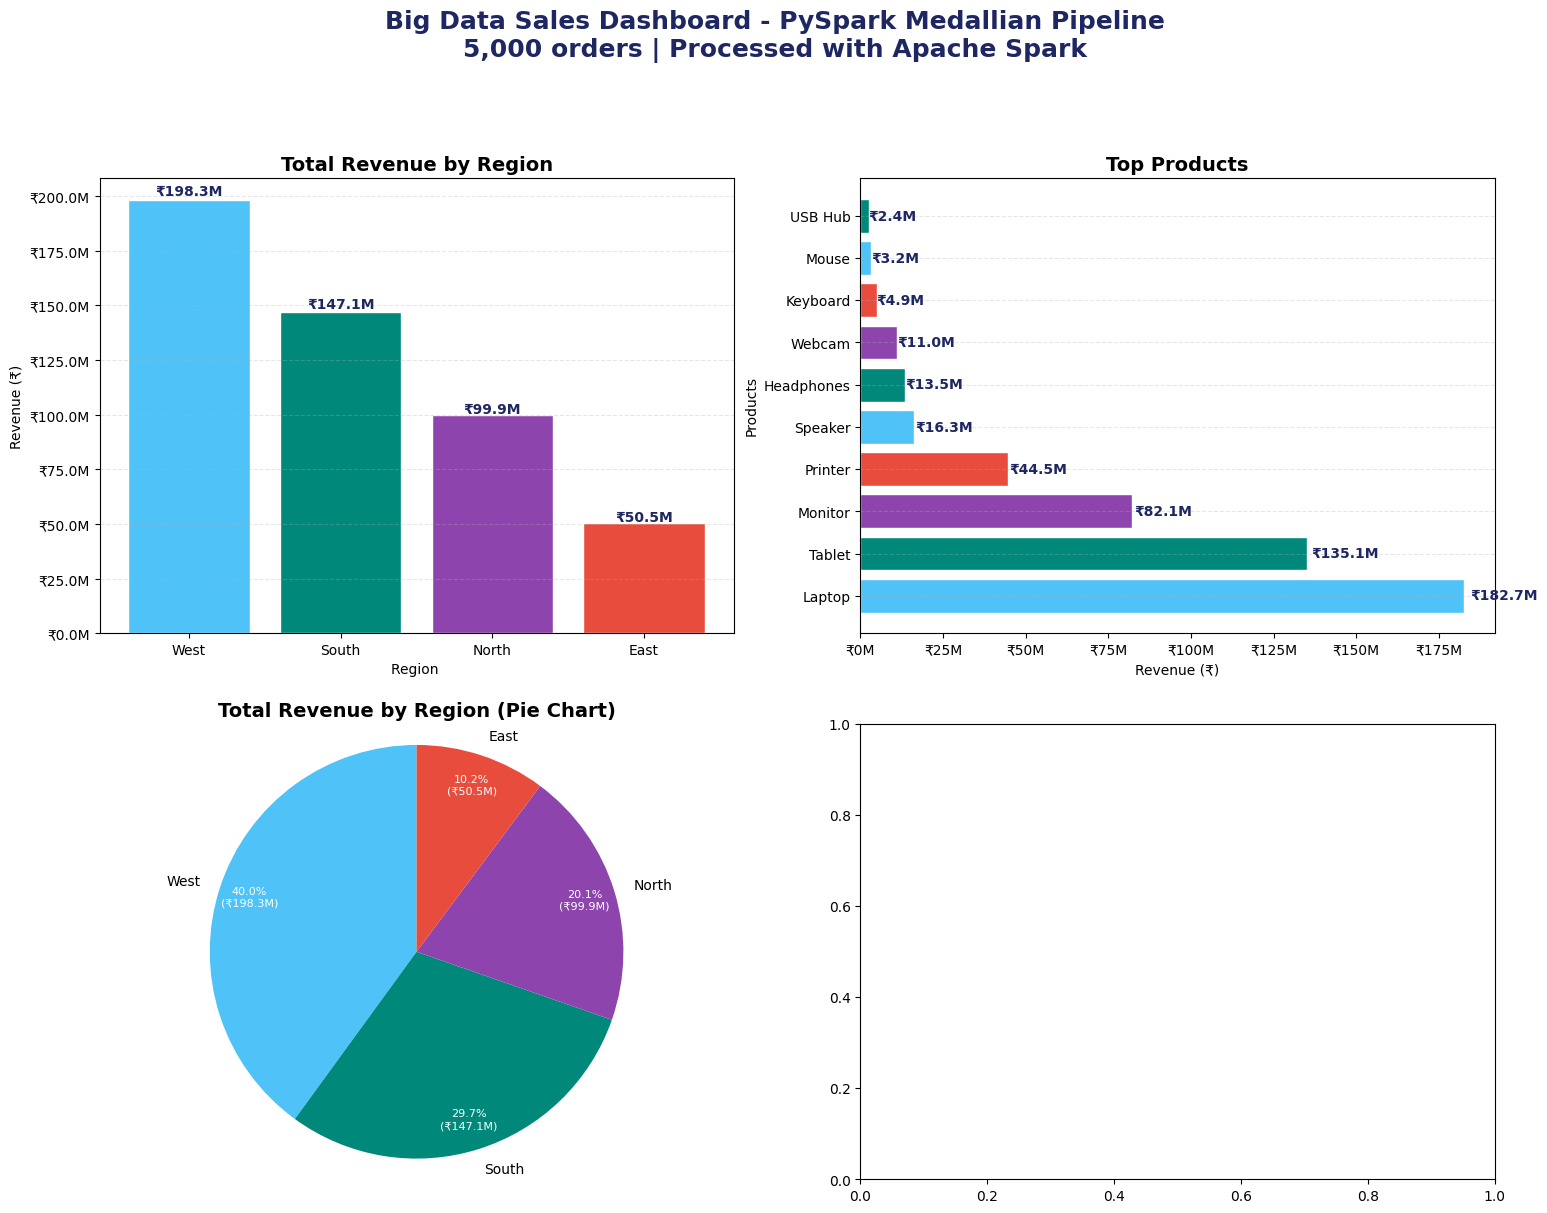

In [ ]:
fig,axes = plt.subplots(2,2,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallian Pipeline\n'
    '5,000 orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold', color='#1E2761', y=1.01
)

colors4= ['#4FC3F7','#00897B','#8E44AD','#E74C3C']

ax1=axes[0][0]
bars1= ax1.bar(region_pd['region'],region_pd['total_revenue'],
               color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
           f'₹{bar.get_height()/1e6:.1f}M',
           ha='center',fontsize=10,fontweight='bold',color='#1E2761')

ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue (₹)')
ax1.set_xlabel('Region ')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2=axes[0][1]
bars2= ax2.barh(products_pd['product'],products_pd['total_revenue'],
               color=colors4[:len(products_pd)],edgecolor='white')

for bar in bars2:
  ax2.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
           f'₹{bar.get_width()/1e6:.1f}M',
           va='center',fontsize=10,fontweight='bold',color='#1E2761')

ax2.set_title('Top Products',fontsize=14,fontweight='bold')
ax2.set_ylabel('Products')
ax2.set_xlabel('Revenue (₹)')
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M')
)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

ax3 = axes[1][0]
wedges, texts, autotexts = ax3.pie(
    region_pd['total_revenue'],
    labels=region_pd['region'],
    autopct=lambda p: f'{p:.1f}%\n(₹{p*sum(region_pd['total_revenue'])/100/1e6:.1f}M)',
    startangle=90,
    colors=colors4[:len(region_pd)],
    pctdistance=0.85
)

for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color('white')

ax3.set_title('Total Revenue by Region (Pie Chart)', fontsize=14, fontweight='bold')
ax3.axis('equal')

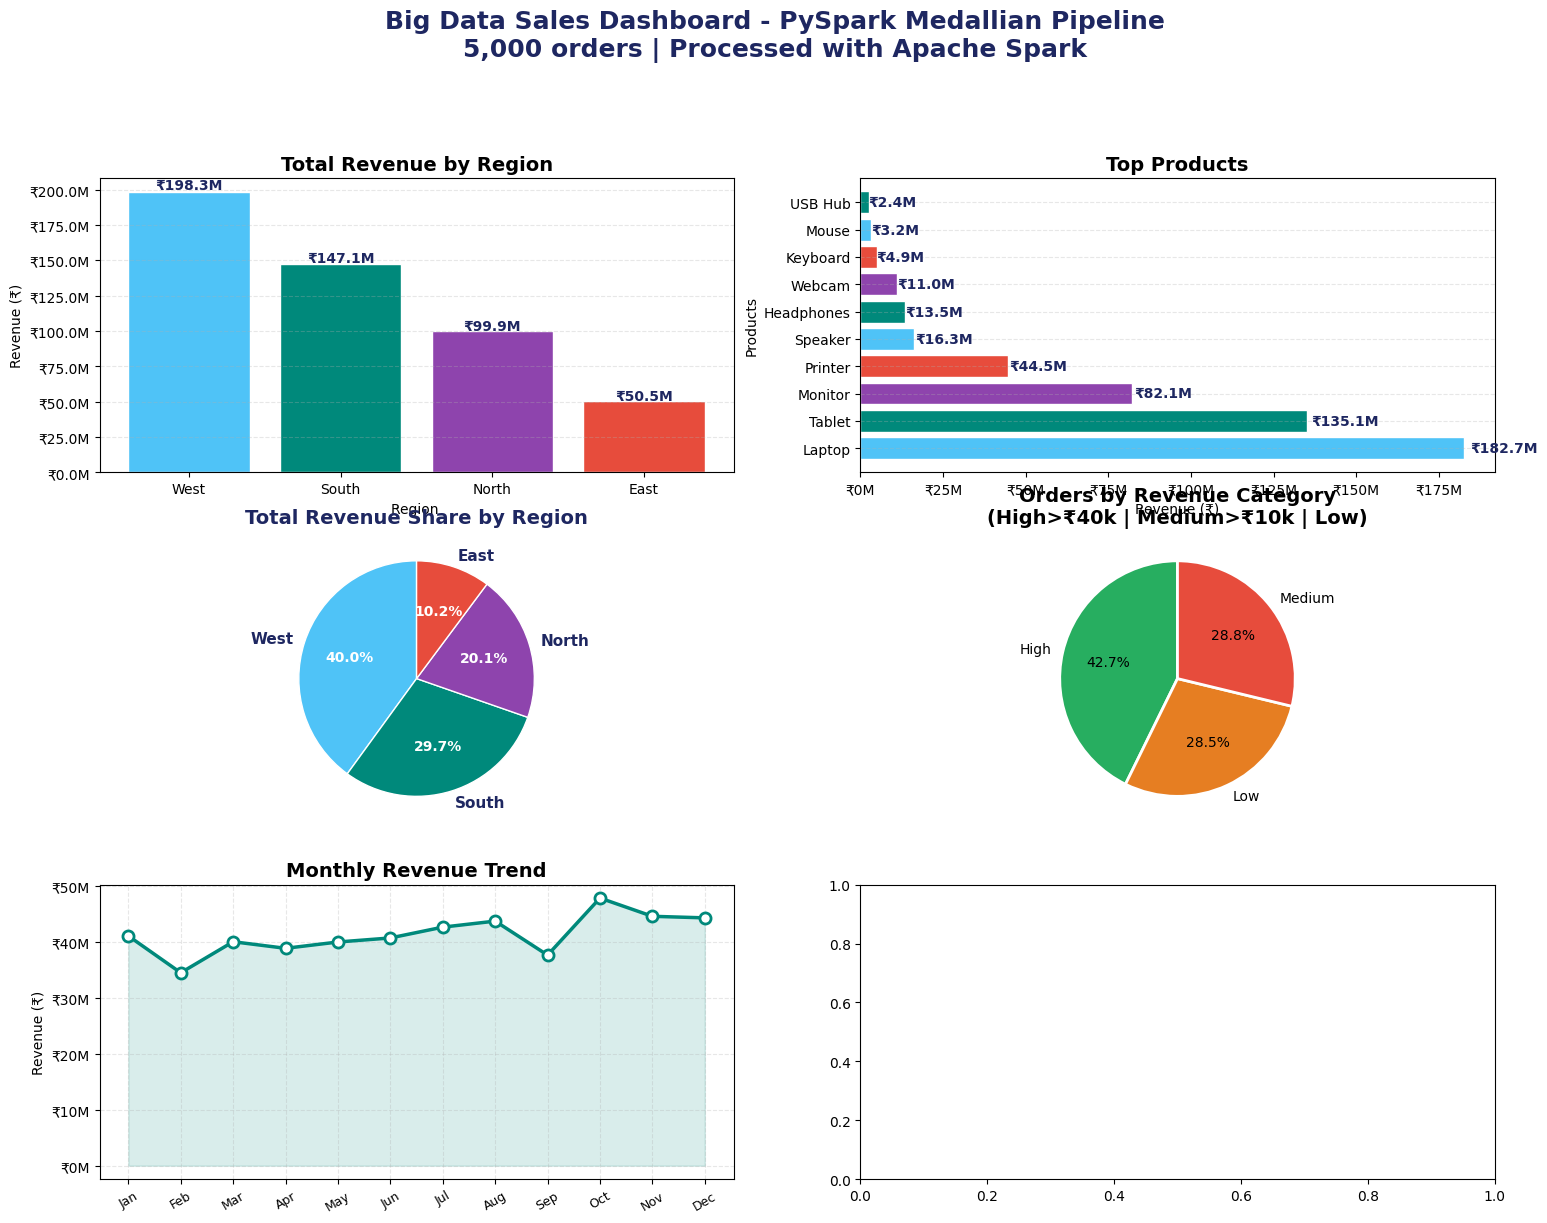

In [ ]:
fig,axes = plt.subplots(3,2,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallian Pipeline\n'
    '5,000 orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold', color='#1E2761', y=1.01
)

colors4= ['#4FC3F7','#00897B','#8E44AD','#E74C3C']

ax1=axes[0][0]
bars1= ax1.bar(region_pd['region'],region_pd['total_revenue'],
               color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
           f'₹{bar.get_height()/1e6:.1f}M',
           ha='center',fontsize=10,fontweight='bold',color='#1E2761')

ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue (₹)')
ax1.set_xlabel('Region ')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2=axes[0][1]
bars2= ax2.barh(products_pd['product'],products_pd['total_revenue'],
               color=colors4[:len(products_pd)],edgecolor='white')

for bar in bars2:
  ax2.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
           f'₹{bar.get_width()/1e6:.1f}M',
           va='center',fontsize=10,fontweight='bold',color='#1E2761')

ax2.set_title('Top Products',fontsize=14,fontweight='bold')
ax2.set_ylabel('Products')
ax2.set_xlabel('Revenue (₹)')
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M')
)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

ax3 = axes[1][0]
wedges, texts, autotexts = ax3.pie(
    region_pd['total_revenue'],
    labels=region_pd['region'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors4[:len(region_pd)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=11, fontweight='bold', color='#1E2761')
ax3.set_title('Total Revenue Share by Region', fontsize=14, fontweight='bold', color='#1E2761')

ax4=axes[1][1]
rev_cat= df_silver.groupBy('revenue_category') \
    .count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=['#27AE60','#E67E22','#E74C3C'],
        autopct='%1.1f%%',startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})


ax4.set_title('Orders by Revenue Category\n(High>₹40k | Medium>₹10k | Low)',fontsize=14,fontweight='bold')

ax5=axes[2][0]
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_labels=[month_names[m-1] for m in monthly_pd['order_month']]

ax5.plot(monthly_labels,monthly_pd['monthly_revenue'],
         marker='o',linewidth=2.5,color='#00897B',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax5.fill_between(range(len(monthly_labels)),
                 monthly_pd['monthly_revenue'],
                 alpha=0.15,color='#00897B')
ax5.set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
ax5.set_ylabel('Revenue (₹)')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M'))
ax5.grid(alpha=0.3,linestyle='--')
ax5.tick_params(axis='x',rotation=30,labelsize=9)